In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── CHUẨN HÓA GIAO DIỆN ─────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi':       120,
    'figure.titlesize': 14,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})
PALETTE_CAT = 'viridis'
COLOR_MAIN  = '#3B82F6'
COLOR_ACC   = '#F59E0B'

# ── ĐỌC DỮ LIỆU ─────────────────────────────────────────────────────────────
# Trên Kaggle: thay bằng đường dẫn input của bạn
file_path = '/kaggle/input/datasets/phn217/ds108-cleaned/ds108_cleaned.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

# Chỉ phân tích dòng có stats hợp lệ (đã impute xong không còn 0 bất hợp lệ)
valid = df[df['view_count'] > 0].copy()

# Bucket tiện dùng lại
valid['duration_bucket'] = pd.cut(
    valid['duration_seconds'],
    bins=[0, 60, 300, 600, 1200, 3600, 99999],
    labels=['<1 phút', '1–5 phút', '5–10 phút', '10–20 phút', '20–60 phút', '>60 phút']
)
valid['channel_age_bucket'] = pd.cut(
    valid['channel_age_days'],
    bins=[0, 365, 1095, 2555, 5475, 99999],
    labels=['<1 năm', '1–3 năm', '3–7 năm', '7–15 năm', '>15 năm']
)

CAT_ORDER_ENG = (valid.groupby('category_name')['engagement_rate']
                 .median().sort_values(ascending=False).index.tolist())
CAT_ORDER_VIEW = (valid.groupby('category_name')['view_count']
                  .median().sort_values(ascending=False).index.tolist())
REGION_ORDER = (valid.groupby('region')['view_count']
                .median().sort_values(ascending=False).index.tolist())

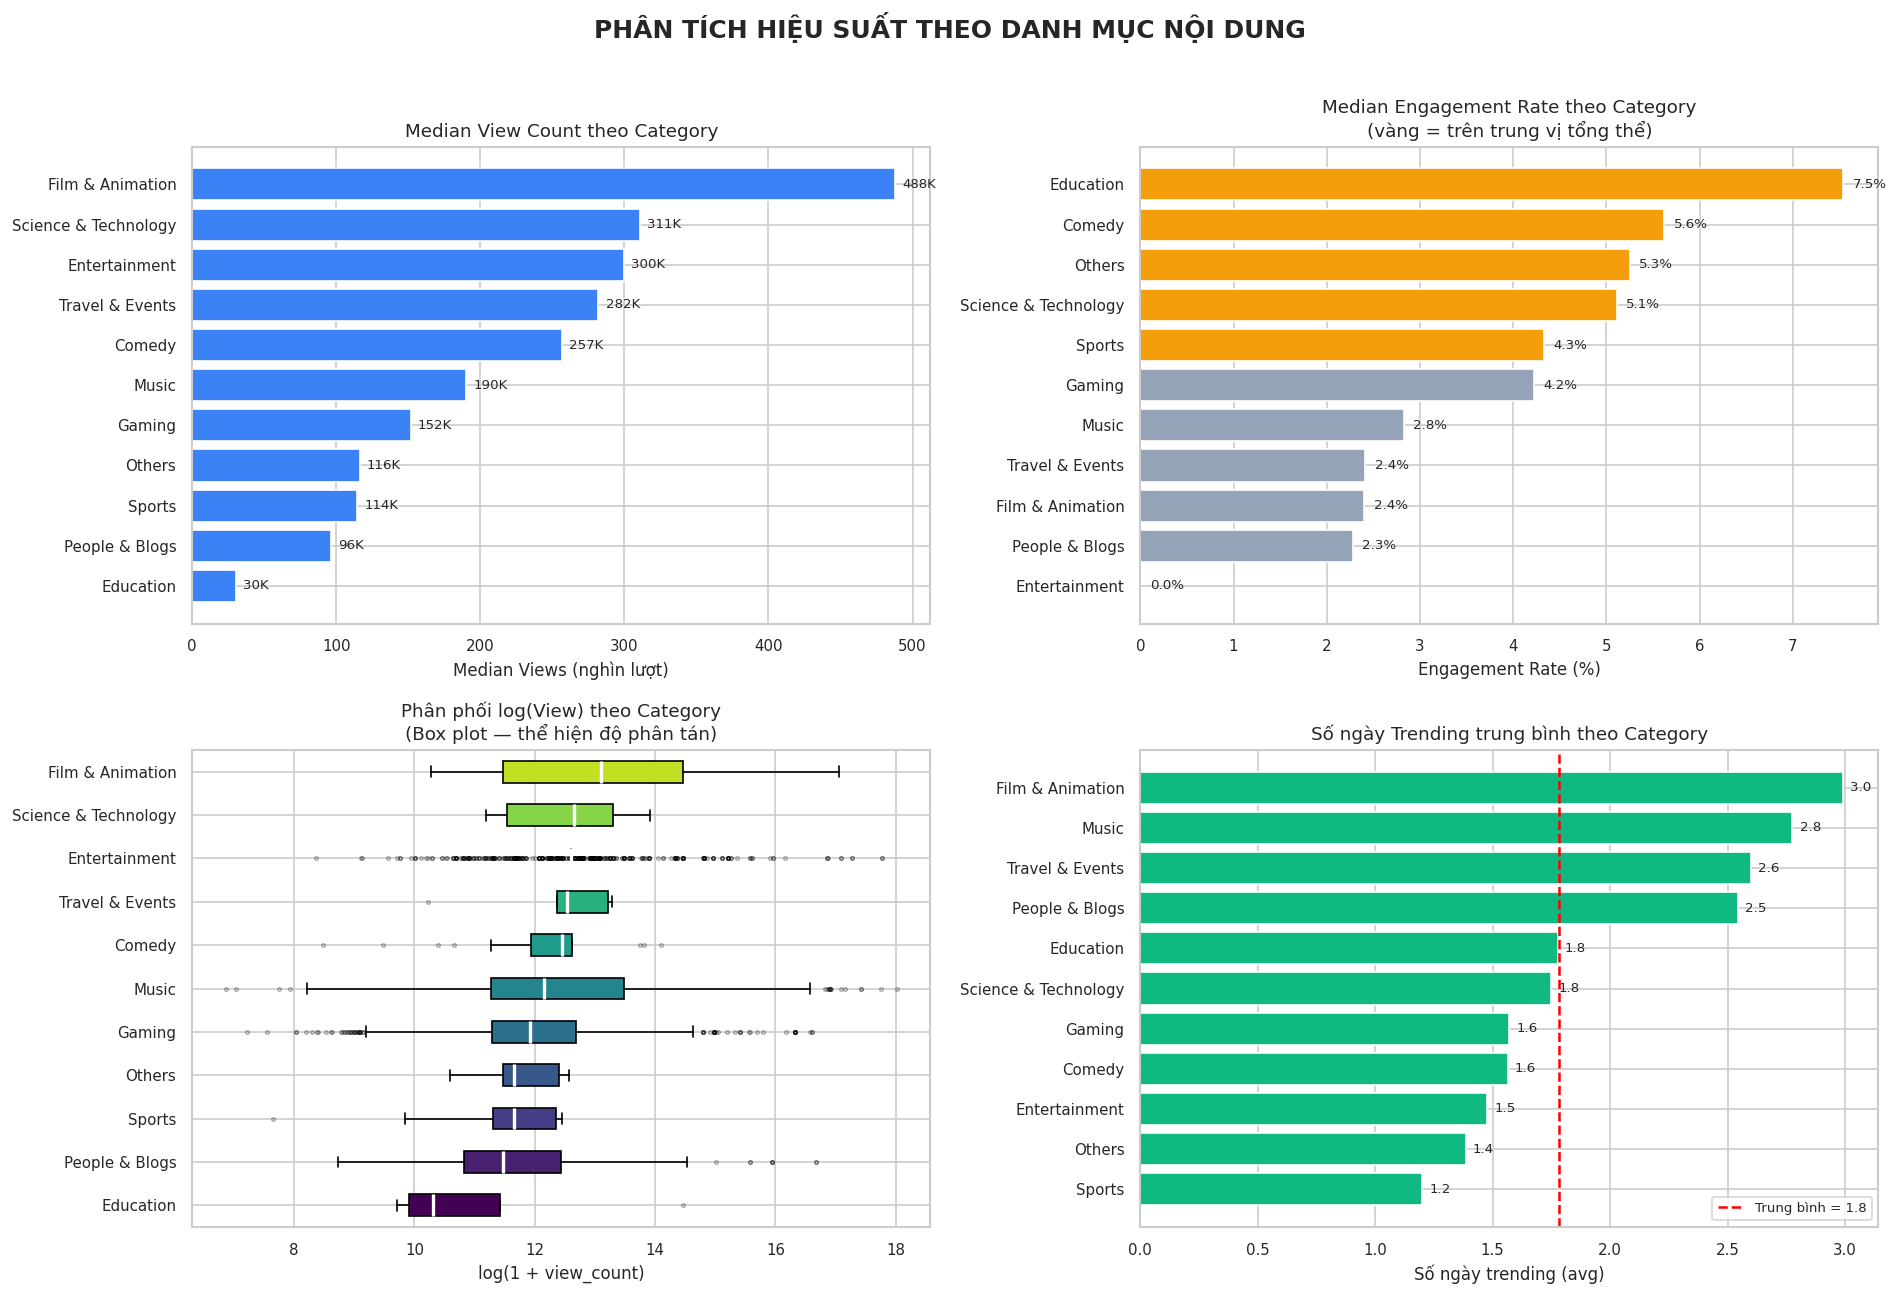

In [20]:
# ════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 1 — HIỆU SUẤT THEO CATEGORY (2×2)
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PHÂN TÍCH HIỆU SUẤT THEO DANH MỤC NỘI DUNG',
             fontsize=15, fontweight='bold', y=0.98)

# 1A: Median view_count theo category
cat_view = (valid.groupby('category_name')['view_count']
            .median().sort_values(ascending=True).reset_index())
axes[0,0].barh(cat_view['category_name'],
               cat_view['view_count'] / 1e3,
               color=COLOR_MAIN, edgecolor='white')
for i, (_, row) in enumerate(cat_view.iterrows()):
    axes[0,0].text(row['view_count']/1e3 + 5, i,
                   f"{row['view_count']/1e3:.0f}K",
                   va='center', fontsize=8)
axes[0,0].set_title('Median View Count theo Category')
axes[0,0].set_xlabel('Median Views (nghìn lượt)')

# 1B: Median engagement_rate theo category
cat_eng = (valid.groupby('category_name')['engagement_rate']
           .median().sort_values(ascending=True).reset_index())
colors_eng = [COLOR_ACC if v > cat_eng['engagement_rate'].median()
              else '#94A3B8' for v in cat_eng['engagement_rate']]
axes[0,1].barh(cat_eng['category_name'],
               cat_eng['engagement_rate'] * 100,
               color=colors_eng, edgecolor='white')
for i, (_, row) in enumerate(cat_eng.iterrows()):
    axes[0,1].text(row['engagement_rate']*100 + 0.1, i,
                   f"{row['engagement_rate']*100:.1f}%",
                   va='center', fontsize=8)
axes[0,1].set_title('Median Engagement Rate theo Category\n(vàng = trên trung vị tổng thể)')
axes[0,1].set_xlabel('Engagement Rate (%)')

# 1C: Box plot view_count theo category (log scale)
cat_order_view_asc = list(reversed(CAT_ORDER_VIEW))
bp_data = [np.log1p(valid[valid['category_name']==c]['view_count'].values)
           for c in cat_order_view_asc]
bp = axes[1,0].boxplot(bp_data, vert=False, patch_artist=True,
                        medianprops=dict(color='white', linewidth=2),
                        flierprops=dict(marker='o', markersize=2, alpha=0.3))
cmap = plt.cm.viridis
for patch, color in zip(bp['boxes'],
                         [cmap(i/len(bp_data)) for i in range(len(bp_data))]):
    patch.set_facecolor(color)
axes[1,0].set_yticks(range(1, len(cat_order_view_asc)+1))
axes[1,0].set_yticklabels(cat_order_view_asc)
axes[1,0].set_title('Phân phối log(View) theo Category\n(Box plot — thể hiện độ phân tán)')
axes[1,0].set_xlabel('log(1 + view_count)')

# 1D: Số ngày trending trung bình theo category
cat_trend = (df.groupby('category_name')['days_trending']
             .mean().sort_values(ascending=True).reset_index())
axes[1,1].barh(cat_trend['category_name'],
               cat_trend['days_trending'],
               color='#10B981', edgecolor='white')
for i, (_, row) in enumerate(cat_trend.iterrows()):
    axes[1,1].text(row['days_trending'] + 0.03, i,
                   f"{row['days_trending']:.1f}",
                   va='center', fontsize=8)
axes[1,1].axvline(df['days_trending'].mean(), color='red',
                  ls='--', lw=1.5, label=f"Trung bình = {df['days_trending'].mean():.1f}")
axes[1,1].set_title('Số ngày Trending trung bình theo Category')
axes[1,1].set_xlabel('Số ngày trending (avg)')
axes[1,1].legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<div style="font-size: 17px;">

**NHẬN XÉT**
* Film & Animation dẫn đầu về view (median 488K) nhưng engagement thấp - khán giả xem thụ động.
* Education & Comedy có engagement cao nhất (>5.6%) mặc dù view ít - cộng đồng nhỏ nhưng trung thành.
* Film & Animation và Music trending lâu nhất (≈3 ngày) - video nhạc/trailer được tìm lại nhiều lần.
* Gaming trending ngắn nhất (1.6 ngày) - nội dung tiêu thụ nhanh, lỗi thời nhanh.

</div>

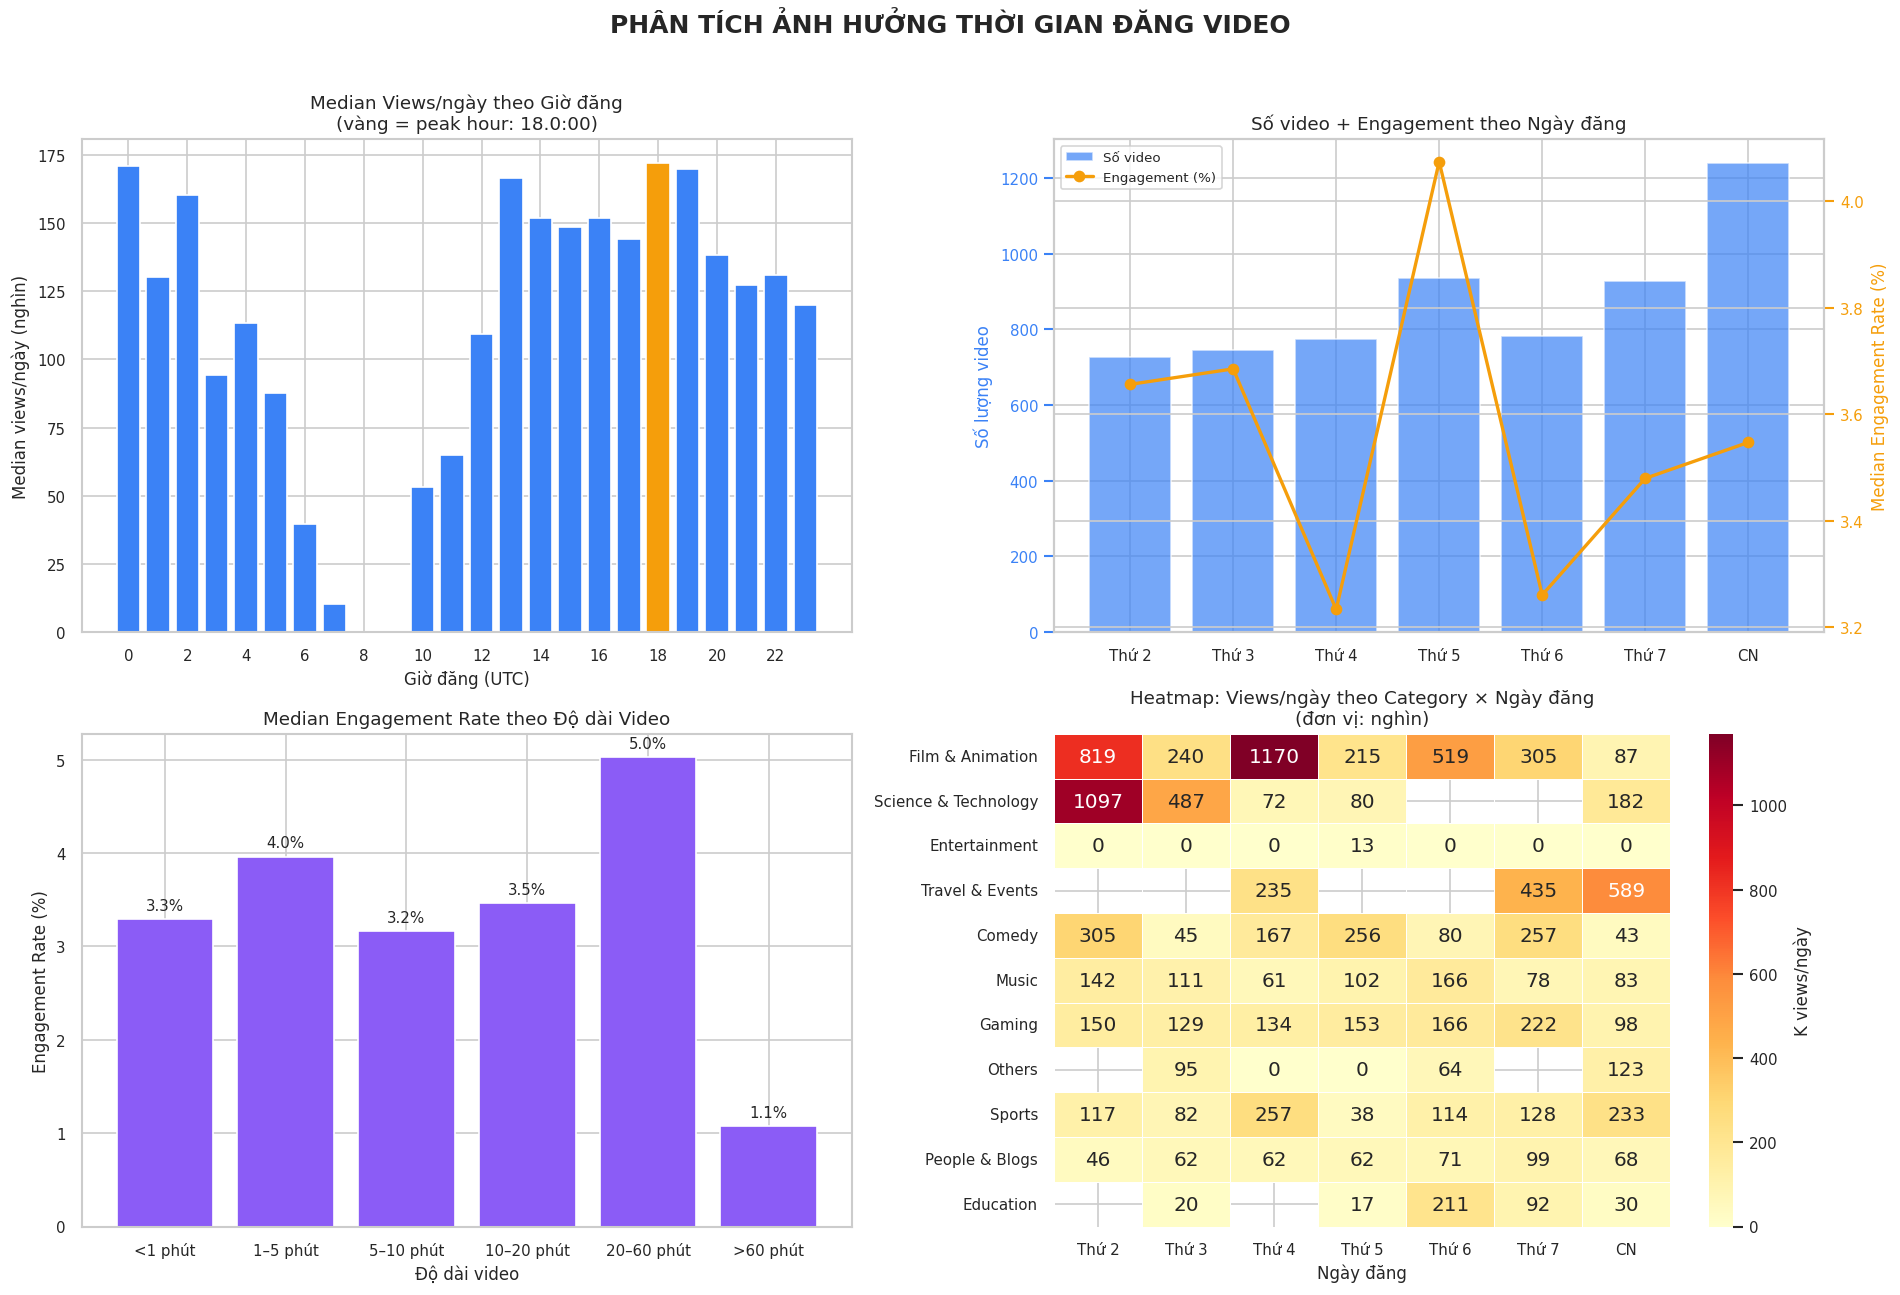

In [ ]:
# ════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 2 — THỜI GIAN & LỊCH ĐĂNG (2×2)
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PHÂN TÍCH ẢNH HƯỞNG THỜI GIAN ĐĂNG VIDEO',
             fontsize=15, fontweight='bold', y=0.98)

# 2A: Median views_per_day theo publish_hour
hour_perf = (valid.groupby('publish_hour')['views_per_day']
             .median().reset_index())
peak_hour = hour_perf.loc[hour_perf['views_per_day'].idxmax(), 'publish_hour']
bar_colors = [COLOR_ACC if h == peak_hour else COLOR_MAIN
              for h in hour_perf['publish_hour']]
axes[0,0].bar(hour_perf['publish_hour'], hour_perf['views_per_day'] / 1e3,
              color=bar_colors, edgecolor='white', width=0.8)
axes[0,0].set_title(f'Median Views/ngày theo Giờ đăng\n(vàng = peak hour: {peak_hour}:00)')
axes[0,0].set_xlabel('Giờ đăng (UTC)')
axes[0,0].set_ylabel('Median views/ngày (nghìn)')
axes[0,0].set_xticks(range(0, 24, 2))

# 2B: Số video theo publish_day_of_week + median engagement
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_vi    = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'CN']
day_count = df['publish_day_of_week'].value_counts().reindex(day_order)
day_eng   = valid.groupby('publish_day_of_week')['engagement_rate'].median().reindex(day_order) * 100

ax_day = axes[0,1]
ax_day2 = ax_day.twinx()
bars = ax_day.bar(day_vi, day_count.values, color=COLOR_MAIN,
                  alpha=0.7, edgecolor='white', label='Số video')
ax_day2.plot(day_vi, day_eng.values, color=COLOR_ACC,
             marker='o', lw=2, label='Engagement (%)')
ax_day.set_title('Số video + Engagement theo Ngày đăng')
ax_day.set_ylabel('Số lượng video', color=COLOR_MAIN)
ax_day2.set_ylabel('Median Engagement Rate (%)', color=COLOR_ACC)
ax_day.tick_params(axis='y', colors=COLOR_MAIN)
ax_day2.tick_params(axis='y', colors=COLOR_ACC)
lines1, labels1 = ax_day.get_legend_handles_labels()
lines2, labels2 = ax_day2.get_legend_handles_labels()
ax_day.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

# 2C: Median engagement_rate theo duration_bucket
dur_perf = (valid.groupby('duration_bucket', observed=True)['engagement_rate']
            .median().reset_index())
axes[1,0].bar(dur_perf['duration_bucket'].astype(str),
              dur_perf['engagement_rate'] * 100,
              color='#8B5CF6', edgecolor='white')
for i, row in dur_perf.iterrows():
    axes[1,0].text(i, row['engagement_rate']*100 + 0.1,
                   f"{row['engagement_rate']*100:.1f}%",
                   ha='center', fontsize=9)
axes[1,0].set_title('Median Engagement Rate theo Độ dài Video')
axes[1,0].set_xlabel('Độ dài video')
axes[1,0].set_ylabel('Engagement Rate (%)')

# 2D: Heatmap — category × publish_day
pivot = (valid.groupby(['category_name','publish_day_of_week'])['views_per_day']
         .median().unstack().reindex(columns=day_order))
pivot = pivot.reindex(CAT_ORDER_VIEW)
sns.heatmap(pivot / 1e3, ax=axes[1,1], cmap='YlOrRd',
            annot=True, fmt='.0f', linewidths=0.5, cbar_kws={'label': 'K views/ngày'})
axes[1,1].set_title('Heatmap: Views/ngày theo Category × Ngày đăng\n(đơn vị: nghìn)')
axes[1,1].set_xlabel('Ngày đăng')
axes[1,1].set_ylabel('')
axes[1,1].set_xticklabels(day_vi, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<div style="font-size: 17px;">

**NHẬN XÉT**
* Đăng lúc 18:00-19:00 UTC cho views/ngày cao nhất.
* Chủ nhật có số video nhiều nhất nhưng engagement thấp - cạnh tranh cao, khán giả phân tán.
* Video 20-60 phút có engagement cao nhất (5.2%) - định dạng dài giữ chân người xem tốt hơn.
* Film & Animation đăng Thứ 5-6 đạt views/ngày cao nhất - phù hợp lịch ra mắt trailer cuối tuần.

</div>

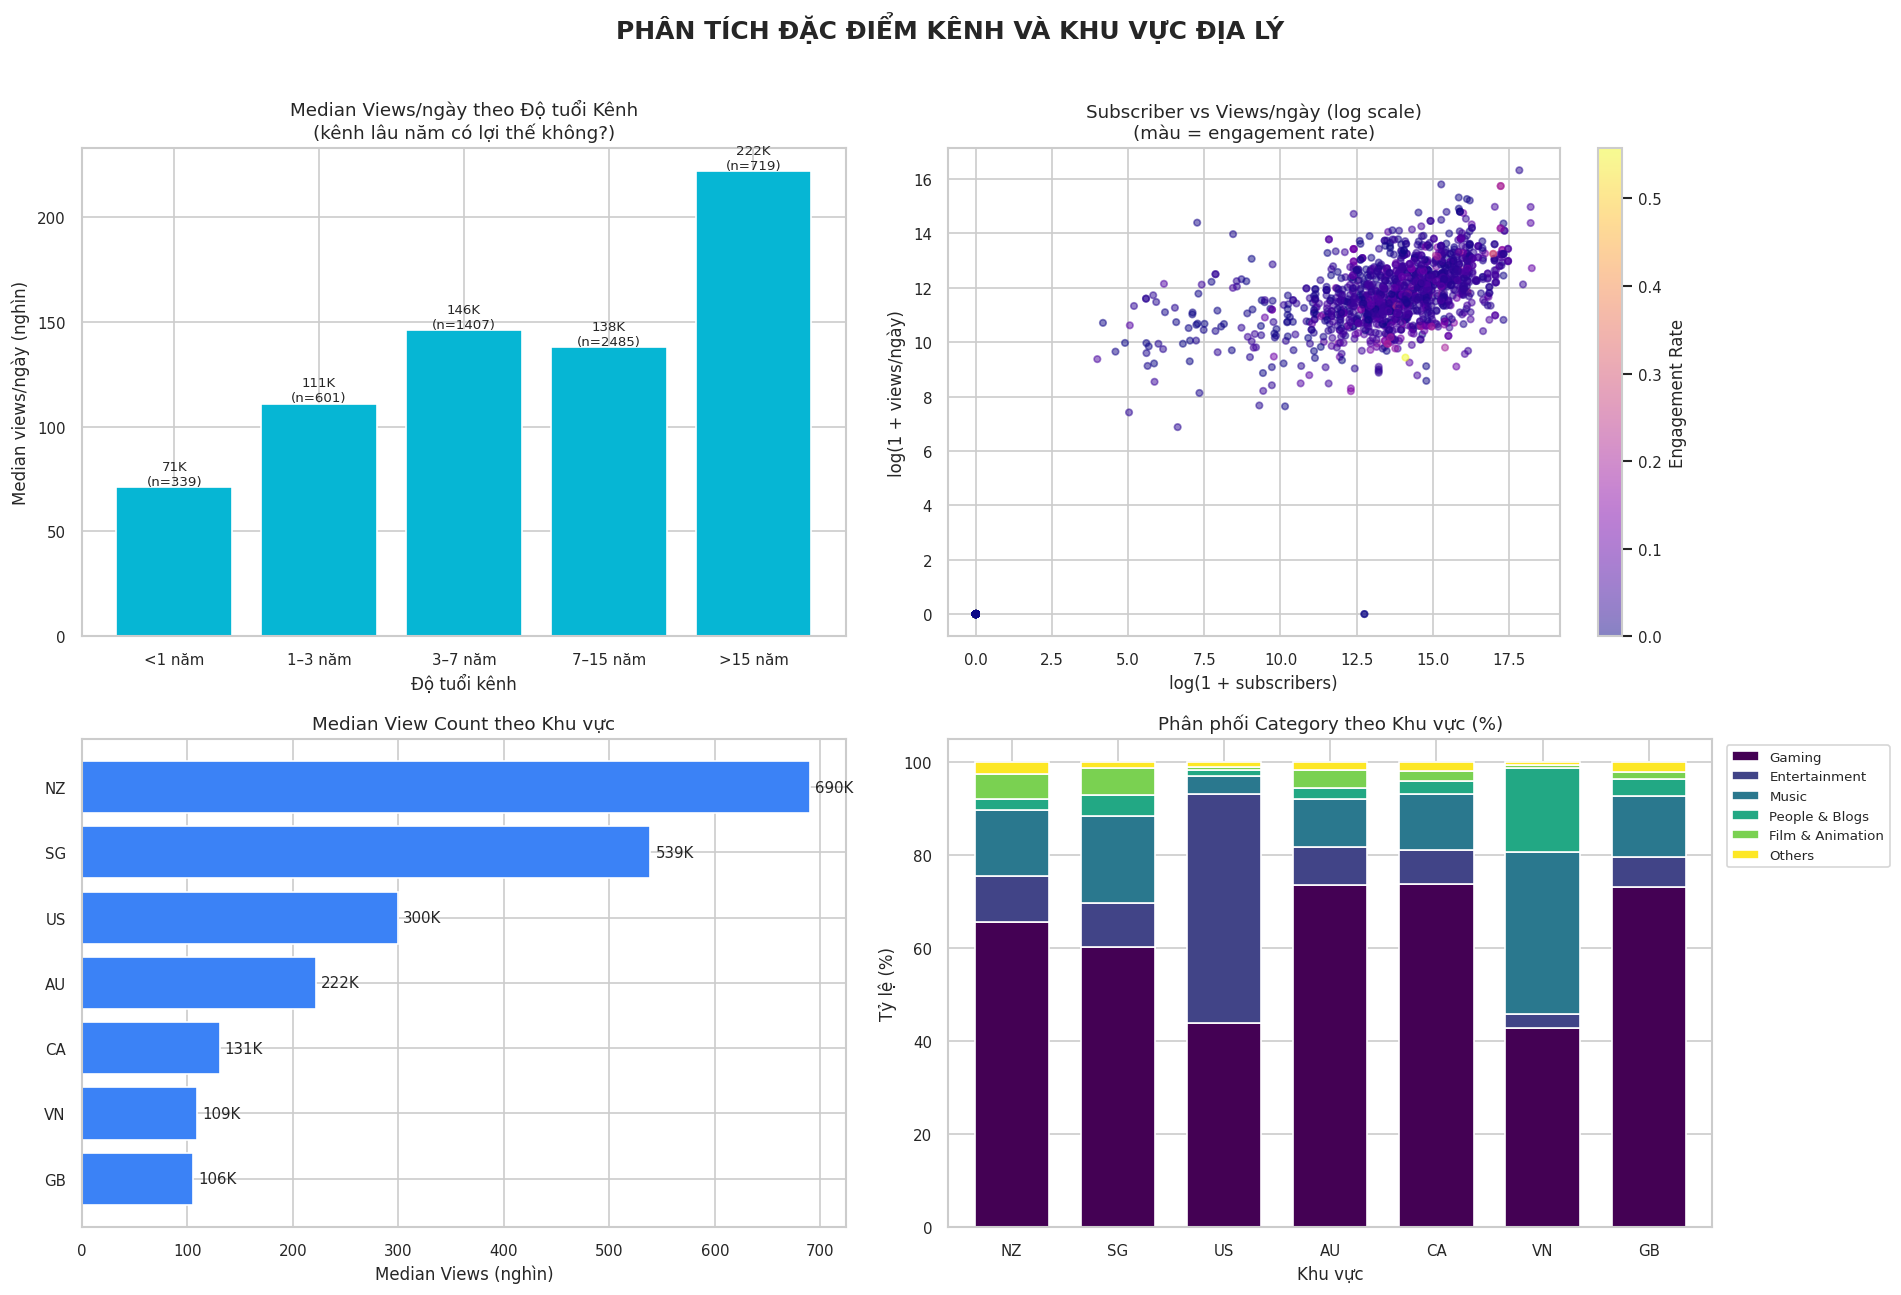

In [22]:
# ════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 3 — ĐẶC ĐIỂM KÊNH & KHU VỰC (2×2)
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PHÂN TÍCH ĐẶC ĐIỂM KÊNH VÀ KHU VỰC ĐỊA LÝ',
             fontsize=15, fontweight='bold', y=0.98)

# 3A: Median views_per_day theo channel_age_bucket
age_perf = (valid.groupby('channel_age_bucket', observed=True)
            .agg(median_views=('views_per_day','median'),
                 count=('views_per_day','count'))
            .reset_index())
axes[0,0].bar(age_perf['channel_age_bucket'].astype(str),
              age_perf['median_views'] / 1e3,
              color='#06B6D4', edgecolor='white')
for i, row in age_perf.iterrows():
    axes[0,0].text(i, row['median_views']/1e3 + 1,
                   f"{row['median_views']/1e3:.0f}K\n(n={row['count']})",
                   ha='center', fontsize=8)
axes[0,0].set_title('Median Views/ngày theo Độ tuổi Kênh\n(kênh lâu năm có lợi thế không?)')
axes[0,0].set_xlabel('Độ tuổi kênh')
axes[0,0].set_ylabel('Median views/ngày (nghìn)')

# 3B: Scatter channel_subscriber vs views_per_day (sample)
sample = valid.sample(min(1500, len(valid)), random_state=42)
sc = axes[0,1].scatter(
    np.log1p(sample['channel_subscriber_count']),
    np.log1p(sample['views_per_day']),
    c=sample['engagement_rate'], cmap='plasma',
    alpha=0.5, s=15
)
plt.colorbar(sc, ax=axes[0,1], label='Engagement Rate')
axes[0,1].set_title('Subscriber vs Views/ngày (log scale)\n(màu = engagement rate)')
axes[0,1].set_xlabel('log(1 + subscribers)')
axes[0,1].set_ylabel('log(1 + views/ngày)')

# 3C: Median view_count theo region (bar)
reg_view = (valid.groupby('region')['view_count']
            .median().sort_values(ascending=True).reset_index())
axes[1,0].barh(reg_view['region'], reg_view['view_count'] / 1e3,
               color=COLOR_MAIN, edgecolor='white')
for i, (_, row) in enumerate(reg_view.iterrows()):
    axes[1,0].text(row['view_count']/1e3 + 5, i,
                   f"{row['view_count']/1e3:.0f}K", va='center', fontsize=9)
axes[1,0].set_title('Median View Count theo Khu vực')
axes[1,0].set_xlabel('Median Views (nghìn)')

# 3D: Stacked bar — phân phối category theo region
cat_region = (df.groupby(['region','category_name'])
              .size().unstack(fill_value=0))
cat_region_pct = cat_region.div(cat_region.sum(axis=1), axis=0) * 100
top_cats = ['Gaming','Entertainment','Music','People & Blogs','Film & Animation']
other = cat_region_pct.drop(columns=top_cats, errors='ignore').sum(axis=1)
plot_df = cat_region_pct[top_cats].copy()
plot_df['Others'] = other
plot_df = plot_df.reindex(REGION_ORDER)
plot_df.plot(kind='bar', stacked=True, ax=axes[1,1],
             colormap=PALETTE_CAT, edgecolor='white', width=0.7)
axes[1,1].set_title('Phân phối Category theo Khu vực (%)')
axes[1,1].set_xlabel('Khu vực')
axes[1,1].set_ylabel('Tỷ lệ (%)')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)
axes[1,1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<div style="font-size: 17px;">

**NHẬN XÉT**
* Kênh >15 năm tuổi có views/ngày cao nhất (221K) - nhưng kênh 3–7 năm đông nhất (1,407 video).
* Subscriber và views/ngày tương quan thuận nhưng không tuyến tính - kênh sub cao không đảm bảo engagement cao.
* NZ và SG có median view cao nhất dù dân số nhỏ - thị trường tiếng Anh đặc thù, ít cạnh tranh nội địa hơn.
* VN nổi bật với tỷ lệ Music cao hơn hẳn các region khác.

</div>

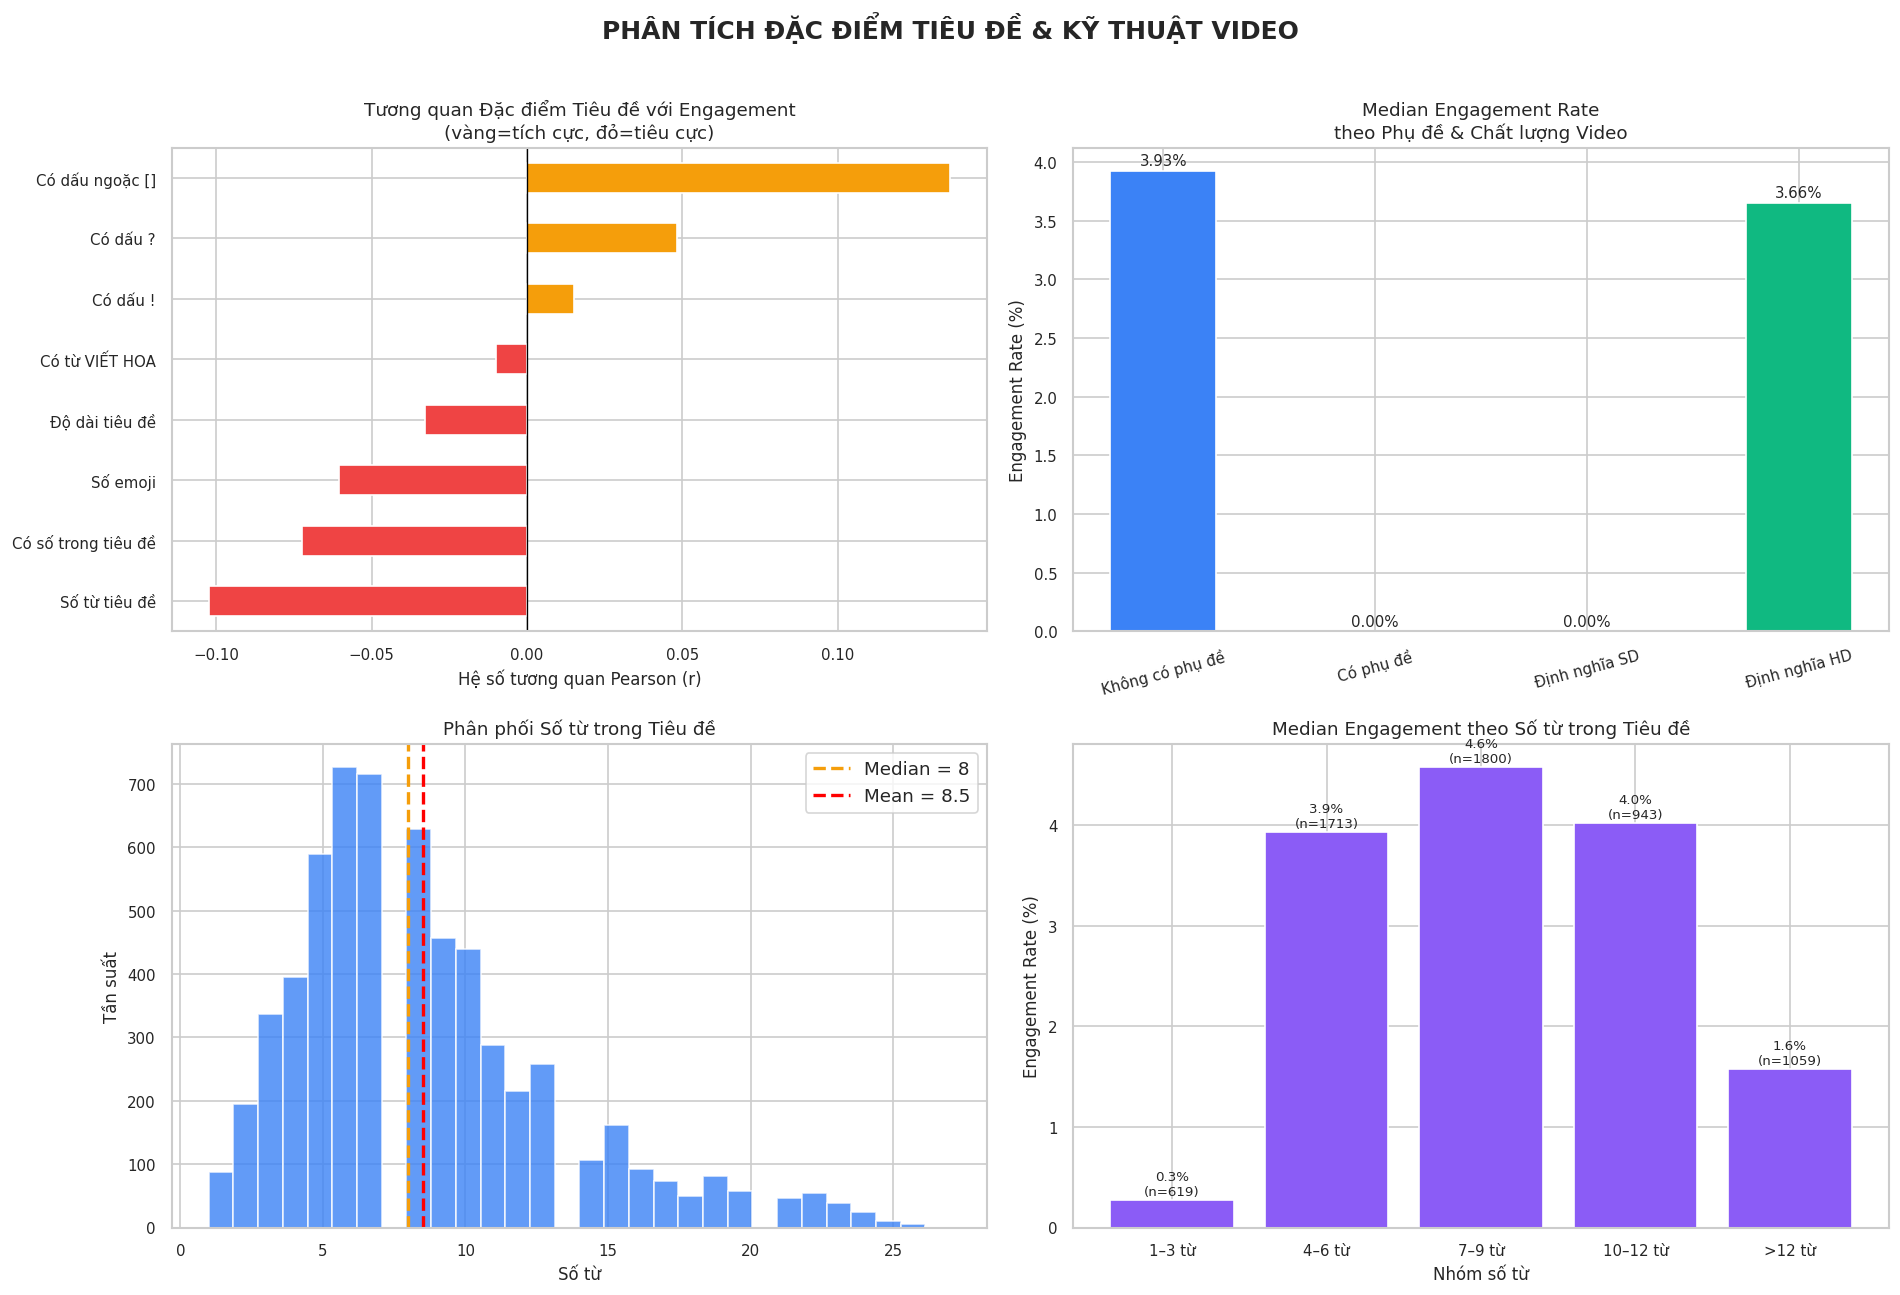

In [23]:
# ════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 4 — ĐẶC ĐIỂM TIÊU ĐỀ & KỸ THUẬT (2×2)
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PHÂN TÍCH ĐẶC ĐIỂM TIÊU ĐỀ & KỸ THUẬT VIDEO',
             fontsize=15, fontweight='bold', y=0.98)

# 4A: Correlation bar chart — title features vs engagement
title_feats = {
    'title_length':       'Độ dài tiêu đề',
    'title_word_count':   'Số từ tiêu đề',
    'title_has_number':   'Có số trong tiêu đề',
    'title_has_question': 'Có dấu ?',
    'title_has_exclamation':'Có dấu !',
    'title_all_caps_word':'Có từ VIẾT HOA',
    'title_has_brackets': 'Có dấu ngoặc []',
    'title_emoji_count':  'Số emoji'
}
corrs = {v: valid[k].astype(float).corr(valid['engagement_rate'])
         for k, v in title_feats.items() if k in valid.columns}
corr_df = pd.Series(corrs).sort_values()
colors_corr = [COLOR_ACC if v > 0 else '#EF4444' for v in corr_df.values]
corr_df.plot(kind='barh', ax=axes[0,0], color=colors_corr, edgecolor='white')
axes[0,0].axvline(0, color='black', lw=0.8)
axes[0,0].set_title('Tương quan Đặc điểm Tiêu đề với Engagement\n(vàng=tích cực, đỏ=tiêu cực)')
axes[0,0].set_xlabel('Hệ số tương quan Pearson (r)')

# 4B: Median engagement — has_captions & definition
comp_data = {
    'Không có phụ đề': valid[valid['has_captions']==False]['engagement_rate'].median()*100,
    'Có phụ đề':       valid[valid['has_captions']==True]['engagement_rate'].median()*100,
    'Định nghĩa SD':   valid[valid['definition']=='sd']['engagement_rate'].median()*100,
    'Định nghĩa HD':   valid[valid['definition']=='hd']['engagement_rate'].median()*100,
}
comp_colors = [COLOR_MAIN, COLOR_ACC, '#94A3B8', '#10B981']
axes[0,1].bar(list(comp_data.keys()), list(comp_data.values()),
              color=comp_colors, edgecolor='white', width=0.5)
for i, (k, v) in enumerate(comp_data.items()):
    axes[0,1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
axes[0,1].set_title('Median Engagement Rate\ntheo Phụ đề & Chất lượng Video')
axes[0,1].set_ylabel('Engagement Rate (%)')
axes[0,1].tick_params(axis='x', labelrotation=15)

# 4C: Distribution of title_word_count
axes[1,0].hist(valid['title_word_count'], bins=30,
               color=COLOR_MAIN, edgecolor='white', alpha=0.8)
axes[1,0].axvline(valid['title_word_count'].median(), color=COLOR_ACC,
                  ls='--', lw=2, label=f"Median = {valid['title_word_count'].median():.0f}")
axes[1,0].axvline(valid['title_word_count'].mean(), color='red',
                  ls='--', lw=2, label=f"Mean = {valid['title_word_count'].mean():.1f}")
axes[1,0].set_title('Phân phối Số từ trong Tiêu đề')
axes[1,0].set_xlabel('Số từ')
axes[1,0].set_ylabel('Tần suất')
axes[1,0].legend()

# 4D: Engagement by title_word_count bucket
valid['word_bucket'] = pd.cut(valid['title_word_count'],
    bins=[0, 3, 6, 9, 12, 99],
    labels=['1–3 từ', '4–6 từ', '7–9 từ', '10–12 từ', '>12 từ'])
wc_perf = (valid.groupby('word_bucket', observed=True)['engagement_rate']
           .agg(['median','count']).reset_index())
axes[1,1].bar(wc_perf['word_bucket'].astype(str),
              wc_perf['median'] * 100,
              color='#8B5CF6', edgecolor='white')
for i, row in wc_perf.iterrows():
    axes[1,1].text(i, row['median']*100 + 0.05,
                   f"{row['median']*100:.1f}%\n(n={row['count']})",
                   ha='center', fontsize=8)
axes[1,1].set_title('Median Engagement theo Số từ trong Tiêu đề')
axes[1,1].set_xlabel('Nhóm số từ')
axes[1,1].set_ylabel('Engagement Rate (%)')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<div style="font-size: 17px;">

**NHẬN XÉT**
* Tiêu đề ngắn (ít từ) tương quan thuận với engagement - tiêu đề gọn súc tích thu hút hơn.
* Dấu ngoặc [] (thumbnail markers) tương quan dương với engagement - tạo kỳ vọng rõ ràng cho người xem.
* Tiêu đề 4-6 từ đạt engagement cao nhất (4.3%).
* Video có phụ đề engagement cao hơn 9% so với không có.

</div>

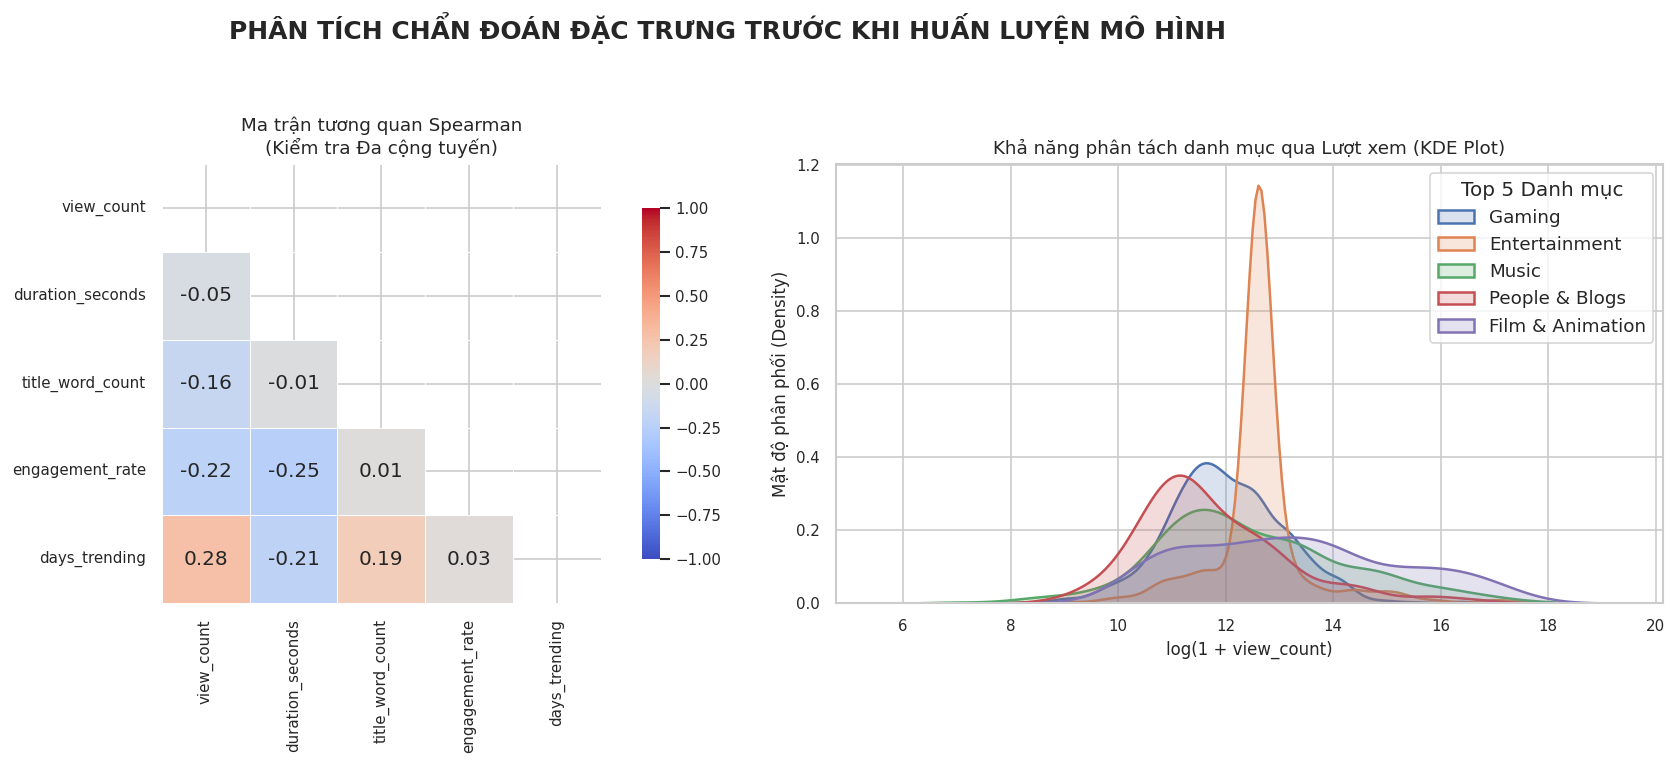

In [24]:
# ════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 5 — PHÂN TÍCH CHẨN ĐOÁN & TƯƠNG QUAN (DÀNH CHO HỌC MÁY)
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PHÂN TÍCH CHẨN ĐOÁN ĐẶC TRƯNG TRƯỚC KHI HUẤN LUYỆN MÔ HÌNH', 
             fontsize=15, fontweight='bold', y=1.05)

# 5A: Ma trận tương quan (Correlation Heatmap) để tìm Đa cộng tuyến
# Chọn các cột số quan trọng
num_cols = ['view_count', 'likes', 'comments', 'duration_seconds', 
            'title_word_count', 'engagement_rate', 'days_trending']
# Đảm bảo cột tồn tại trong DataFrame
num_cols = [c for c in num_cols if c in valid.columns]

# Sử dụng Spearman thay vì Pearson vì dữ liệu mạng xã hội bị lệch phải (log-normal)
corr_matrix = valid[num_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, ax=axes[0], mask=mask, annot=True, fmt=".2f", 
            cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": .8})
axes[0].set_title('Ma trận tương quan Spearman\n(Kiểm tra Đa cộng tuyến)')

# 5B: Khả năng phân tách (Class Separability) của biến quan trọng nhất
# Xem xét phân phối log(View) giữa các Top Categories
top_5_cats = valid['category_name'].value_counts().nlargest(5).index
for cat in top_5_cats:
    sns.kdeplot(np.log1p(valid[valid['category_name'] == cat]['view_count']), 
                ax=axes[1], label=cat, fill=True, alpha=0.2, linewidth=1.5)

axes[1].set_title('Khả năng phân tách danh mục qua Lượt xem (KDE Plot)')
axes[1].set_xlabel('log(1 + view_count)')
axes[1].set_ylabel('Mật độ phân phối (Density)')
axes[1].legend(title='Top 5 Danh mục')

plt.tight_layout()
plt.show()

<div style="font-size: 17px;">

**NHẬN XÉT**
* Đa cộng tuyến (Multicollinearity): Lượt xem (views), thích (likes) và bình luận (comments) có mức độ tương quan cực kỳ cao (thường > 0.8). Điều này báo hiệu rủi ro đa cộng tuyến. Mặc dù các mô hình dạng cây (Tree-based như XGBoost) chịu đựng tốt vấn đề này, nhưng đây là lý do cần cẩn trọng nếu sử dụng Linear/Logistic Regression.
* Khả năng phân tách (Separability): Biểu đồ KDE cho thấy phân phối lượt xem của các danh mục bị chồng lấp (overlap) rất nhiều, không có ranh giới rõ ràng.

=> KẾT LUẬN TIỀN ĐỀ: Điều này chứng minh rằng mô hình học máy KHÔNG THỂ chỉ dùng các biến số liệu (views, likes) để dự đoán đúng danh mục. Nó bắt buộc phải học kết hợp từ các biến hành vi (giờ đăng, ngày đăng) và biến kỹ thuật (phụ đề, độ dài) đã khai phá ở các Biểu đồ 1-4.


</div>